In [1]:
import matplotlib.pyplot as plt
import numpy as np
import re
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator
import math

from common import (
    get_dataset_sort_key,
    INDEX_ORDER,
    index_colors,
    index_hatches,
    format_dataset_label,
    apply_style,
    save_fig,
    DATASET_PROPS,
    PLOT_DPI,
    LABEL_FONTSIZE,
    TICK_FONTSIZE,
    X_TICK_FONTSIZE,
    BAR_LABEL_FONTSIZE,
    FONT_COLOR,
    TICK_FONTS_COLOR,
    BAR_TEXT_COLOR,
)

# ---------------------------------------------------------------------------
# 1. Manually collected index size data (in bytes)
# ---------------------------------------------------------------------------
# VSS (v1.4.4): CALL pragma_hnsw_index_info(); Default: ef_construction = 128, M = 16, M0 = 32.
# - LOAD vss; SET hnsw_enable_experimental_persistence = true; DROP INDEX IF EXISTS test_idx; CREATE INDEX test_idx ON test_table USING HNSW (embedding) WITH (ef_construction = 128, M = 16, M0 = 32); CALL pragma_hnsw_index_info();
# pgvector (see docker-compose.yml): https://github.com/pgvector/pgvector/issues/276
# - psql -h localhost -p 5432 -U postgres vectordb -c "SELECT pg_relation_size('pgvector_index');"
# - HNSW: --m 16 --ef-construction 128
# - IVFFlat: --lists (see PGVECTOR_IVFFLAT_LISTS in utils.py)
# PDX (9df687b): CALL pdxearch_index_info();
# - DROP INDEX IF EXISTS test_idx; CREATE INDEX test_idx ON test_table USING PDXEARCH (embedding) WITH (quantization = 'f32', seed = 0, metric = 'cosine'); CALL pdxearch_index_info();
# Structure: dataset_name → index_type → size in bytes
# Datasets match the case names used in index_creation.ipynb
data = {
    "Cohere (1M × 768)": {
        "DuckDB VSS (HNSW)":                          4558821312,
        "pgvector (HNSW)":                             4095680512,
        "pgvector (IVFFlat)":                          4102119424,
        "DuckDB PDXearch (IVF, Global, F32)":          3087096192,
        "DuckDB PDXearch (IVF, Global, U8)":           783096208,
        "DuckDB PDXearch (IVF, Row Group, F32)":       3098223376,
        "DuckDB PDXearch (IVF, Row Group, U8)":        794223520,
    },
    "OpenAI (500K × 1536)": {
        "DuckDB VSS (HNSW)":                          4420603648,
        "pgvector (HNSW)":                             4096008192,
        "pgvector (IVFFlat)":                          4100104192,
        "DuckDB PDXearch (IVF, Global, F32)":          3081084192,
        "DuckDB PDXearch (IVF, Global, U8)":           777084208,
        "DuckDB PDXearch (IVF, Row Group, F32)":       3093719152,
        "DuckDB PDXearch (IVF, Row Group, U8)":        789719232,
    },
    "Agnews (769K × 1024)": {
        "DuckDB VSS (HNSW)":                          4556976368,
        "pgvector (HNSW)":                             6256967680,
        "pgvector (IVFFlat)":                          6309093376,
        "DuckDB PDXearch (IVF, Global, F32)":          3163793848,
        "DuckDB PDXearch (IVF, Global, U8)":           800252360,
        "DuckDB PDXearch (IVF, Row Group, F32)":       3175191704,
        "DuckDB PDXearch (IVF, Row Group, U8)":        811650312,
    },
    "SIFT (4999K × 128)": {
        "DuckDB VSS (HNSW)":                          5396119552,
        "pgvector (HNSW)":                             4159668224,
        "pgvector (IVFFlat)":                          2739937280,
        "DuckDB PDXearch (IVF, Global, F32)":          2620674688,
        "DuckDB PDXearch (IVF, Global, U8)":           701058704,
        "DuckDB PDXearch (IVF, Row Group, F32)":       2630342768,
        "DuckDB PDXearch (IVF, Row Group, U8)":        710727424,
    },
    "ArxivForFanns (1.2M × 1024)": {
        "DuckDB VSS (HNSW)":                          8855388608,
        "pgvector (HNSW)":                             9826623488,
        "pgvector (IVFFlat)":                          9839386624,
        "DuckDB PDXearch (IVF, Global, F32)":          4934115712,
        "DuckDB PDXearch (IVF, Global, U8)":           1247715728,
        "DuckDB PDXearch (IVF, Row Group, F32)":       4949607832,
        "DuckDB PDXearch (IVF, Row Group, U8)":        1263207992,
    },
    "Cohere (6M × 768)": {
        "DuckDB VSS (HNSW)":                           36542809344,
        "pgvector (HNSW)":                             None,
        "pgvector (IVFFlat)":                          None,
        "DuckDB PDXearch (IVF, Global, F32)":          18576731856,
        "DuckDB PDXearch (IVF, Global, U8)":           4704071392,
        # "DuckDB PDXearch (IVF, Global 256/cl, F32)":          None,
        # "DuckDB PDXearch (IVF, Global 256/cl, U8)":           None,
        "DuckDB PDXearch (IVF, Row Group, F32)":       18641958824,
        "DuckDB PDXearch (IVF, Row Group, U8)":        4769299128,
    },
}

def format_bytes(n: float, precision_is_zero: bool = False) -> str:
    """Format a byte count as a human-readable string."""
    if abs(n) < 1024:
        return f"{n:.0f} B"
    for unit in ('KiB', 'MiB', 'GiB', 'TiB'):
        n /= 1024
        if abs(n) < 1024:
            if precision_is_zero:
                return f"{n:.0f} {unit}"
            else:
                return f"{n:.2f} {unit}"
    if precision_is_zero:
        return f"{n:.0f} PiB"
    else:
        return f"{n:.2f} PiB"

In [2]:
# ---------------------------------------------------------------------------
# 2. Dataset ordering
# ---------------------------------------------------------------------------

datasets = sorted(data.keys(), key=get_dataset_sort_key)

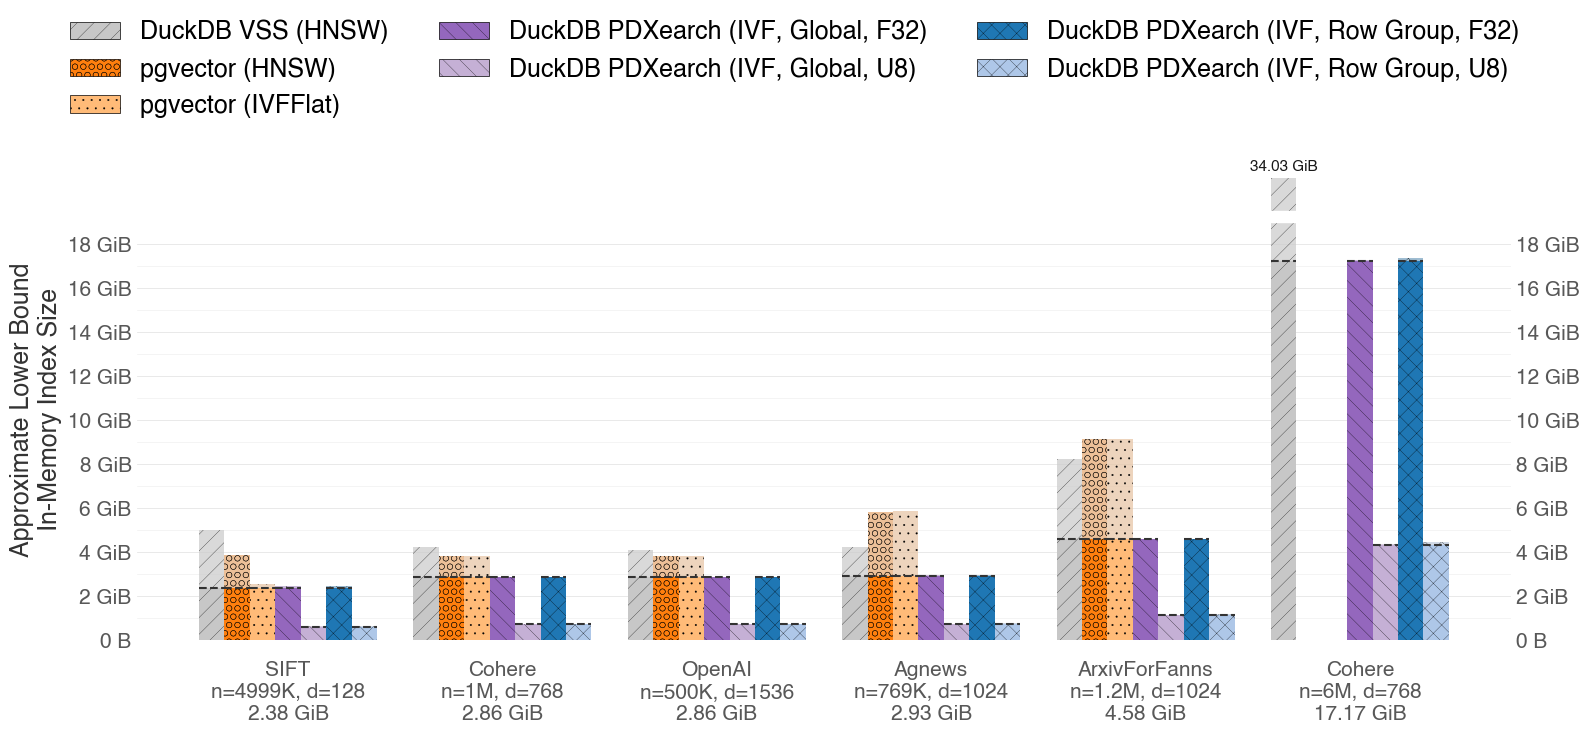

In [3]:
# ---------------------------------------------------------------------------
# 3. Bar plot: absolute index size (labels show overhead and total)
# ---------------------------------------------------------------------------

apply_style()

# Reference line styling (dashed line at embeddings baseline)
REF_F32_COLOR = '#333333'
REF_U8_COLOR  = '#333333'

# Which raw baseline to use for the embeddings segment (F32 vs U8).
# F32 indexes are compared against raw F32, U8 indexes against raw U8.
INDEX_BASELINE = {
    "DuckDB VSS (HNSW)":                          "f32",
    "pgvector (HNSW)":                             "f32",
    "pgvector (IVFFlat)":                          "f32",
    "DuckDB PDXearch (IVF, Global, F32)":          "f32",
    "DuckDB PDXearch (IVF, Global, U8)":           "u8",
    "DuckDB PDXearch (IVF, Row Group, F32)":       "f32",
    "DuckDB PDXearch (IVF, Row Group, U8)":        "u8",
}

# Determine which index types are actually present (non-None values)
all_index_types = []
for idx in INDEX_ORDER:
    for ds in datasets:
        if data[ds].get(idx) is not None:
            all_index_types.append(idx)
            break
n_index_types = len(all_index_types)

bar_width = 0.35 # 0.7
group_width = n_index_types * bar_width + 0.2
group_spacing = 0.3

from matplotlib.ticker import FuncFormatter, AutoMinorLocator
from matplotlib.colors import to_rgb

def lower_contrast_color(color, gray=0.6, blend=0.5):
    """Return a lower-contrast (more muted) version by blending with gray."""
    rgb = to_rgb(color)
    return tuple((1 - blend) * gray + blend * c for c in rgb)

def bytes_formatter(val, pos):
    return format_bytes(val, precision_is_zero=True)

def gib(num):
    return 1024 ** 3 * num

# Cap & break: bars taller than BAR_CAP are drawn up to BAR_CAP with a
# broken_barh gap from BREAK_LO to BREAK_HI to indicate truncation.
BAR_CAP  = gib(21)
BREAK_LO = gib(19)
BREAK_HI = gib(19.5)

fig, ax1 = plt.subplots(1, 1, figsize=(16, 7)) # 25, 5

def draw_bars(ax, value_fn, ylabel, show_label=False):
    """Draw grouped bars on ax. value_fn(dataset, index_type, raw_f32, raw_u8) → float or None."""
    x_base = 0
    x_labels = []
    group_centers = []
    for dataset in datasets:
        group_start = x_base
        has_data = False

        props = DATASET_PROPS.get(dataset, {})
        n_emb = props.get("n", 0)
        dim   = props.get("d", 0)
        raw_f32 = n_emb * dim * 4
        raw_u8  = n_emb * dim * 1

        for idx_idx, index_type in enumerate(all_index_types):
            val = value_fn(dataset, index_type, raw_f32, raw_u8)
            if val is None:
                continue
            has_data = True
            x = group_start + idx_idx * bar_width
            baseline = raw_f32 if INDEX_BASELINE.get(index_type, "f32") == "f32" else raw_u8
            overhead = val - baseline
            color = index_colors.get(index_type, "#808080")
            color_muted = lower_contrast_color(color, gray=0.8, blend=0.5)
            hatch = index_hatches.get(index_type, "")

            capped = val > BAR_CAP
            draw_val = BAR_CAP if capped else val
            draw_overhead = draw_val - baseline

            if capped:
                # Draw two segments with a gap using broken_barh.
                # Segment 1: 0 → BREAK_LO (split into baseline + overhead portion)
                x_left = x - bar_width / 2
                # Bottom segment: embeddings baseline (full color)
                ax.broken_barh(
                    [(x_left, bar_width)], (0, baseline),
                    facecolors=color, hatch=hatch, zorder=2,
                )
                # Overhead portion below the break
                if baseline < BREAK_LO:
                    ax.broken_barh(
                        [(x_left, bar_width)], (baseline, BREAK_LO - baseline),
                        facecolors=color_muted, hatch=hatch, alpha=0.70, zorder=2,
                    )
                # Segment 2: BREAK_HI → BAR_CAP (overhead continues above gap)
                ax.broken_barh(
                    [(x_left, bar_width)], (BREAK_HI, BAR_CAP - BREAK_HI),
                    facecolors=color_muted, hatch=hatch, alpha=0.70, zorder=2,
                    label=index_type if dataset == datasets[0] else "",
                )
                # White-out the gap region to create the visual break
                ax.broken_barh(
                    [(x_left, bar_width)], (BREAK_LO, BREAK_HI - BREAK_LO),
                    facecolors='white', edgecolors='white', zorder=3,
                )
                # Label showing actual size
                ax.text(x, BAR_CAP * 1.01, f"{format_bytes(val)}",
                        ha="center", va="bottom", fontsize=BAR_LABEL_FONTSIZE, color=BAR_TEXT_COLOR,
                        fontweight="bold")
            else:
                # Normal (uncapped) stacked bar
                ax.bar(x, baseline, bar_width, color=color, hatch=hatch, label="")
                ax.bar(x, draw_overhead, bar_width, bottom=baseline, color=color_muted, hatch=hatch,
                       alpha=0.70, label=index_type if dataset == datasets[0] else "")

                offset = max(1, abs(val) * 0.03)
                if show_label:
                    label_text = f"{format_bytes(overhead)}\n({format_bytes(val)})"
                else:
                    label_text = None
                x_text = x
                ax.text(x_text, val + offset, label_text,
                        ha="center", va="bottom", fontsize=BAR_LABEL_FONTSIZE - 2, color=BAR_TEXT_COLOR)

            # Dashed reference line at embeddings baseline (top of bottom segment)
            ref_color = REF_F32_COLOR if INDEX_BASELINE.get(index_type, "f32") == "f32" else REF_U8_COLOR
            x_left = x - bar_width / 2
            x_right = x + bar_width / 2
            ax.hlines(baseline, x_left, x_right, colors=ref_color, linewidths=1.5,
                      linestyles='--', zorder=5)

        if has_data:
            center = group_start + (n_index_types - 1) * bar_width / 2
            group_centers.append(center)
            x_labels.append(format_dataset_label(dataset))

            x_base += group_width + group_spacing

    ax.yaxis.set_major_formatter(FuncFormatter(bytes_formatter))
    ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE, color=FONT_COLOR)
    ax.set_xticks(group_centers)
    ax.set_xticklabels(x_labels, fontsize=X_TICK_FONTSIZE, color=TICK_FONTS_COLOR)
    ax.yaxis.grid(True, linestyle='-', linewidth=0.6, color='gray', alpha=0.2)
    ax.set_axisbelow(True)
    for spine in ('top', 'right', 'left', 'bottom'):
        ax.spines[spine].set_visible(False)
    ax.set_yticks([gib(i) for i in range(0, 19, 2)])
    ax.set_ylim(0, gib(21))
    ax.tick_params(axis='y', which='both', colors=TICK_FONTS_COLOR, length=0, labelsize=TICK_FONTSIZE)
    ax.tick_params(axis='both', length=0)
    ax.tick_params(axis='x', pad=15)

    # Faint minor gridlines halfway between major gridlines (stop at 19 GiB)
    from matplotlib.ticker import FixedLocator
    ax.yaxis.set_minor_locator(FixedLocator([gib(i) for i in range(1, 19, 2)]))
    ax.yaxis.grid(True, which='minor', linestyle='-', linewidth=0.4, color='gray', alpha=0.15)
    ax.tick_params(axis='y', which='minor', length=0)

    # Mirror y-axis ticks on the right side
    ax2 = ax.secondary_yaxis('right')
    ax2.set_yticks(ax.get_yticks())
    ax2.yaxis.set_major_formatter(FuncFormatter(bytes_formatter))
    ax2.tick_params(axis='y', colors=TICK_FONTS_COLOR, length=0, labelsize=TICK_FONTSIZE)
    ax2.spines['right'].set_visible(False)

# Plot 1: absolute index size
def absolute_value(dataset, index_type, raw_f32, raw_u8):
    return data[dataset].get(index_type)

draw_bars(ax1, absolute_value, "Approximate Lower Bound\nIn-Memory Index Size", show_label=False)
# draw_bars(ax1, absolute_value, "Approximate Lower Bound\nIn-Memory Index Size", show_label=True)

# Shared legend
legend_handles = [
    Patch(facecolor=index_colors.get(idx, "#808080"),
          hatch=index_hatches.get(idx, ""),
          edgecolor='black', linewidth=0.5,
          label=idx)
    for idx in all_index_types
]
fig.legend(handles=legend_handles, loc="upper center", ncols=math.ceil(len(all_index_types) / 3),
           frameon=False, fontsize=LABEL_FONTSIZE, bbox_to_anchor=(0.5, 1.06))

fig.tight_layout(rect=[0, 0, 1, 0.85])
# fig.tight_layout(rect=[0, 0, 1, 1])
save_fig("index_size")


In [4]:
vss_key = "DuckDB VSS (HNSW)"
pdx_keys = [
    "DuckDB PDXearch (IVF, Row Group, F32)",
    "DuckDB PDXearch (IVF, Row Group, U8)",
]

for pdx_key in pdx_keys:
    pct_diffs = {}
    for dataset, sizes in data.items():
        vss_size = sizes[vss_key]
        pdx_size = sizes[pdx_key]
        pct_diffs[dataset] = (1 - pdx_size / vss_size) * 100

    min_ds = min(pct_diffs, key=pct_diffs.get)
    max_ds = max(pct_diffs, key=pct_diffs.get)

    label = pdx_key.split(",")[-1].strip().rstrip(")")
    print(f"{pdx_key} vs {vss_key}:")
    print("-" * 70)
    for dataset, pct in sorted(pct_diffs.items(), key=lambda x: x[1]):
        vss = data[dataset][vss_key]
        pdx = data[dataset][pdx_key]
        print(f"  {dataset}: {format_bytes(pdx)} vs {format_bytes(vss)} → {pct:.1f}% reduction")
    print("-" * 70)
    print(f"Range: {pct_diffs[min_ds]:.1f}% to {pct_diffs[max_ds]:.1f}% reduction")
    print()

DuckDB PDXearch (IVF, Row Group, F32) vs DuckDB VSS (HNSW):
----------------------------------------------------------------------
  OpenAI (500K × 1536): 2.88 GiB vs 4.12 GiB → 30.0% reduction
  Agnews (769K × 1024): 2.96 GiB vs 4.24 GiB → 30.3% reduction
  Cohere (1M × 768): 2.89 GiB vs 4.25 GiB → 32.0% reduction
  ArxivForFanns (1.2M × 1024): 4.61 GiB vs 8.25 GiB → 44.1% reduction
  Cohere (6M × 768): 17.36 GiB vs 34.03 GiB → 49.0% reduction
  SIFT (4999K × 128): 2.45 GiB vs 5.03 GiB → 51.3% reduction
----------------------------------------------------------------------
Range: 30.0% to 51.3% reduction

DuckDB PDXearch (IVF, Row Group, U8) vs DuckDB VSS (HNSW):
----------------------------------------------------------------------
  OpenAI (500K × 1536): 753.13 MiB vs 4.12 GiB → 82.1% reduction
  Agnews (769K × 1024): 774.05 MiB vs 4.24 GiB → 82.2% reduction
  Cohere (1M × 768): 757.43 MiB vs 4.25 GiB → 82.6% reduction
  ArxivForFanns (1.2M × 1024): 1.18 GiB vs 8.25 GiB → 85.7% redu

In [5]:
# ---------------------------------------------------------------------------
# LaTeX table: overhead / total size per system × dataset
# ---------------------------------------------------------------------------

# Build short dataset column headers from sorted dataset list
def short_dataset_name(ds: str) -> str:
    """E.g. 'Cohere (1M × 768)' → 'Cohere1M', 'SIFT (4999K × 128)' → 'SIFT'."""
    import re
    name = ds.split("(")[0].strip()
    # Extract the row-count part (e.g. "1M", "6M") to disambiguate duplicates
    m = re.search(r"\((\d+\.?\d*[KMB]?)\s*[×x]", ds)
    count_tag = m.group(1) if m else ""
    return name + count_tag

# Deduplicate: if a short name appears more than once, keep the tag; otherwise drop it
_raw_short = [short_dataset_name(ds) for ds in datasets]
_base_names = [ds.split("(")[0].strip() for ds in datasets]
from collections import Counter
_base_counts = Counter(_base_names)

def short_dataset_name_dedup(ds: str) -> str:
    base = ds.split("(")[0].strip()
    if _base_counts[base] > 1:
        return short_dataset_name(ds)
    return base

col_headers = [short_dataset_name_dedup(ds) for ds in datasets]
n_cols = len(datasets)

# Build short system row labels
def short_system_name(idx: str) -> str:
    """Shorten index type names for the table."""
    return idx.replace("DuckDB ", "").replace("(IVF, ", "(").replace(")", ")")

def right_align_size(s: str) -> str:
    """Wrap a size string so the number is right-aligned against the unit."""
    if s == "--":
        return s
    # Split into number and unit, e.g. "2.88 GiB" → "2.88" "GiB"
    parts = s.rsplit(" ", 1)
    if len(parts) == 2:
        return rf"\rlap{{{parts[1]}}}\hphantom{{GiB}}{parts[0]}"
    return s

lines = []

lines.append(r"\begin{table}[ht]")
lines.append(r"\centering")
lines.append(r"\caption{Approximate lower bound of in-memory index size across datasets and systems.}")
lines.append(r"\label{tab:index_size}")
lines.append(r"\makebox[\textwidth]{%")
lines.append(r"\resizebox{1.2\textwidth}{!}{%")

col_spec = "l l|" + " r" * n_cols
lines.append(r"\begin{tabular}{" + col_spec + "}")
lines.append(r"\toprule")

# Header row: dataset names
header = " & ".join(
    [r"\textbf{System}", ""]
    + [rf"\textbf{{{h}}}" for h in col_headers]
) + r" \\"
lines.append(header)
lines.append(r"\midrule")

# First row: raw F32 embeddings size per dataset
emb_cells = []
for ds in datasets:
    props = DATASET_PROPS.get(ds, {})
    n_emb = props.get("n", 0)
    dim = props.get("d", 0)
    raw_f32 = n_emb * dim * 4
    emb_cells.append(format_bytes(raw_f32))

emb_row = " & ".join(
    [r"Raw embeddings (F32)", ""]
    + emb_cells
) + r" \\"
lines.append(emb_row)
lines.append(r"\midrule")

for i, index_type in enumerate(all_index_types):
    baseline_type = INDEX_BASELINE.get(index_type, "f32")
    row_label = short_system_name(index_type)

    overhead_cells = []
    total_cells = []
    pct_cells = []
    for ds in datasets:
        props = DATASET_PROPS.get(ds, {})
        n_emb = props.get("n", 0)
        dim = props.get("d", 0)
        raw = n_emb * dim * (4 if baseline_type == "f32" else 1)
        total = data[ds].get(index_type)
        if total is None:
            overhead_cells.append("--")
            total_cells.append("--")
            pct_cells.append("--")
        else:
            overhead = total - raw
            pct = (overhead / total) * 100
            overhead_cells.append(format_bytes(overhead))
            total_cells.append(format_bytes(total))
            pct_cells.append(f"{pct:.1f}\\%")

    # Overhead row: system name spans 3 rows via \multirow
    overhead_row = " & ".join(
        [rf"\multirow{{3}}{{*}}{{{row_label}}}", r"\textit{Overhead}"]
        + overhead_cells
    ) + r" \\"
    lines.append(overhead_row)

    # Total row
    total_row = " & ".join(
        ["", r"\textit{Total}"]
        + total_cells
    ) + r" \\"
    lines.append(total_row)

    # Percentage row
    pct_row = " & ".join(
        ["", r"\textit{Overhead \%}"]
        + pct_cells
    ) + r" \\"
    lines.append(pct_row)

    # Separator between systems (but not after the last one)
    if i < len(all_index_types) - 1:
        lines.append(r"\midrule")

lines.append(r"\bottomrule")
lines.append(r"\end{tabular}")
lines.append(r"}}")
lines.append(r"\end{table}")

latex_table = "\n".join(lines)
print(latex_table)

\begin{table}[ht]
\centering
\caption{Approximate lower bound of in-memory index size across datasets and systems.}
\label{tab:index_size}
\makebox[\textwidth]{%
\resizebox{1.2\textwidth}{!}{%
\begin{tabular}{l l| r r r r r r}
\toprule
\textbf{System} &  & \textbf{SIFT} & \textbf{Cohere1M} & \textbf{OpenAI} & \textbf{Agnews} & \textbf{ArxivForFanns} & \textbf{Cohere6M} \\
\midrule
Raw embeddings (F32) &  & 2.38 GiB & 2.86 GiB & 2.86 GiB & 2.93 GiB & 4.58 GiB & 17.23 GiB \\
\midrule
\multirow{3}{*}{VSS (HNSW)} & \textit{Overhead} & 2.64 GiB & 1.38 GiB & 1.26 GiB & 1.31 GiB & 3.67 GiB & 16.81 GiB \\
 & \textit{Total} & 5.03 GiB & 4.25 GiB & 4.12 GiB & 4.24 GiB & 8.25 GiB & 34.03 GiB \\
 & \textit{Overhead \%} & 52.6\% & 32.6\% & 30.5\% & 30.8\% & 44.5\% & 49.4\% \\
\midrule
\multirow{3}{*}{pgvector (HNSW)} & \textit{Overhead} & 1.49 GiB & 976.26 MiB & 976.57 MiB & 2.89 GiB & 4.57 GiB & -- \\
 & \textit{Total} & 3.87 GiB & 3.81 GiB & 3.81 GiB & 5.83 GiB & 9.15 GiB & -- \\
 & \textit{Overh